<a href="https://colab.research.google.com/github/cermegno/langgraph-learning/blob/main/02%20-%20nvidia-inference-memory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Nvidia Inference with history
Graph for Multi-turn Nvidia inference with memory and LLM in a chain.

In [2]:
!pip install langgraph langchain-nvidia-ai-endpoints --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.4 MB/s eta 0:00:00


In [3]:
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, START, END
from langgraph.graph import add_messages
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import BaseMessage
from langchain_nvidia_ai_endpoints import ChatNVIDIA

In [4]:
class State(TypedDict):
  # 'add_messages' is a reducer that appends new messages automatically
  messages: Annotated[list[BaseMessage], add_messages]

In [5]:
from google.colab import userdata
apikey = userdata.get('apikey')

In [17]:
from langchain_core.messages import HumanMessage

llm = ChatNVIDIA(
    base_url = "https://integrate.api.nvidia.com/v1",
    api_key = apikey,
    model="meta/llama-3.1-8b-instruct"
    )

prompt = ChatPromptTemplate.from_messages(
    [
        ("system", "You are a helpful assistant."),
        ("placeholder", "{messages}"),
    ]
)

chain = prompt | llm

def call_nvidia_llm(state: State) -> State:
  """Calls Nvidia LLM and updates state"""
  response = chain.invoke({"messages": state['messages']})
  return {"messages": [response]}
#print(call_nvidia_llm({"messages": [HumanMessage(content="Hi, I am Tim")]}))

In [18]:
graph = StateGraph(State)
graph.add_node("llm_node", call_nvidia_llm)
graph.add_edge(START, "llm_node")
graph.add_edge("llm_node", END)
app = graph.compile()

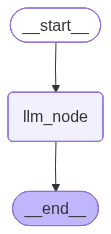

In [19]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [23]:
result = app.invoke({"messages": [HumanMessage(content="Hi, I am Tim")]})

In [24]:
from pprint import pprint
pprint(result)

{'messages': [HumanMessage(content='Hi, I am Tim', additional_kwargs={}, response_metadata={}, id='e8cae209-db80-4ce4-8962-f530599d4af9'),
              AIMessage(content="Hello Tim, it's nice to meet you. Is there something I can help you with today?", additional_kwargs={}, response_metadata={'content': "Hello Tim, it's nice to meet you. Is there something I can help you with today?", 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 46, 'completion_tokens': 21, 'total_tokens': 67, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 32}}, 'finish_reason': 'stop', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--019e4e3d-db2c-7c40-8838-4385be703e3a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 21, 'total_tokens': 67}, role='assistant')]}


In [25]:
history = result['messages'] + [HumanMessage(content="Hi, do you remember my name?")]
result = app.invoke({"messages": history })
pprint(result)

{'messages': [HumanMessage(content='Hi, I am Tim', additional_kwargs={}, response_metadata={}, id='e8cae209-db80-4ce4-8962-f530599d4af9'),
              AIMessage(content="Hello Tim, it's nice to meet you. Is there something I can help you with today?", additional_kwargs={}, response_metadata={'content': "Hello Tim, it's nice to meet you. Is there something I can help you with today?", 'role': 'assistant', 'reasoning_content': None, 'token_usage': {'prompt_tokens': 46, 'completion_tokens': 21, 'total_tokens': 67, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 32}}, 'finish_reason': 'stop', 'model_name': 'meta/llama-3.1-8b-instruct'}, id='lc_run--019e4e3d-db2c-7c40-8838-4385be703e3a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 46, 'output_tokens': 21, 'total_tokens': 67}, role='assistant'),
              HumanMessage(content='Hi, do you remember my name?', additional_kwargs={}, response_metadata={}, id='85167921-75cc-41d3-93bf-b144a6eff5ad'